In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from astropy.io import fits
from astropy.table import Table
from astropy.table import vstack
import os

from scipy import stats
import tensorflow as tf
import tensorflow_datasets as tfds
import keras_tuner as kt
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import pickle

2025-05-13 10:51:05.955896: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747147865.984917   40236 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747147865.993847   40236 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747147866.016267   40236 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747147866.016300   40236 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747147866.016303   40236 computation_placer.cc:177] computation placer alr

### Import data

In [2]:
fits_file_2384a = '/work/mccleary_group/saha/data/Abell2384a/sextractor_dualmode/out/Abell2384a_colors_mags.fits'
hdul_2384a = fits.open(fits_file_2384a)
data_2384a = Table(hdul_2384a[1].data)

fits_file_2384b = '/work/mccleary_group/saha/data/Abell2384b/sextractor_dualmode/out/Abell2384b_colors_mags.fits'
hdul_2384b = fits.open(fits_file_2384b)
data_2384b = Table(hdul_2384b[1].data)

fits_file_3667 = '/work/mccleary_group/saha/data/Abell3667/sextractor_dualmode/out/Abell3667_colors_mags.fits'
hdul_3667 = fits.open(fits_file_3667)
data_3667 = Table(hdul_3667[1].data)

fits_file_3571 = '/work/mccleary_group/saha/data/Abell3571/sextractor_dualmode/out/Abell3571_colors_mags.fits'
hdul_3571 = fits.open(fits_file_3571)
data_3571 = Table(hdul_3571[1].data)

fits_file_3827 = '/work/mccleary_group/saha/data/Abell3827/sextractor_dualmode/out/Abell3827_colors_mags.fits'
hdul_3827 = fits.open(fits_file_3827)
data_3827 = Table(hdul_3827[1].data)

data = vstack([data_2384a, data_2384b, data_3667, data_3571, data_3827])

redshift_col = 'Z_best'
data_z = data[~np.isnan(np.array(data[redshift_col])) & (np.array(data[redshift_col]) > 0)]
x_cols = ['m_b', 'm_g', 'm_u', 'R_b', 'R_g',  'R_u']

x = np.array([data_z[x_cols[i]] for i in range(len(x_cols))]).T
y = np.array([data_z[redshift_col]]).T

### Import model

In [3]:
path = os.getcwd() + '/Tensorflow_models/mlp_redshift.keras'

check_model = tf.keras.models.load_model(path)

2025-05-13 09:54:02.681768: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Compare true and predicted redshifts

305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step


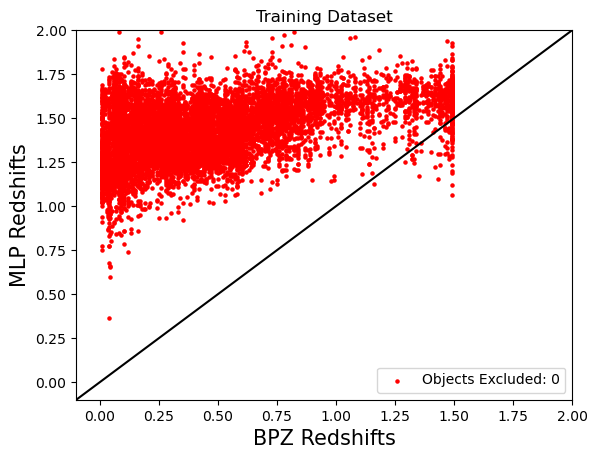

In [4]:
model_out = check_model.predict(x)

plot_bool = (model_out > 0 ) & (model_out < 5)

ob_excluded = len(np.where(~plot_bool)[0])

plt.scatter(y, model_out, c='r', label = f'Objects Excluded: {ob_excluded}', s=5)

mod_min = np.min(model_out[plot_bool])
mod_max = np.max(model_out[plot_bool])
line = np.linspace(mod_min - 5, mod_max + 5, 100)
plt.plot(line, line, c='k')

plt.xlim(-0.1, 2)
plt.ylim(-0.1, 2)

plt.title('Training Dataset')
plt.xlabel('BPZ Redshifts', fontsize = 15)
plt.ylabel('MLP Redshifts', fontsize = 15)

plt.legend()

# CNN

### Pick a suffix (this is temporary)

In [5]:
suffix = '_im'

### Visualize Vignettes

/home/habjan.e/miniconda3/envs/sb_metacal/lib/python3.12/site-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


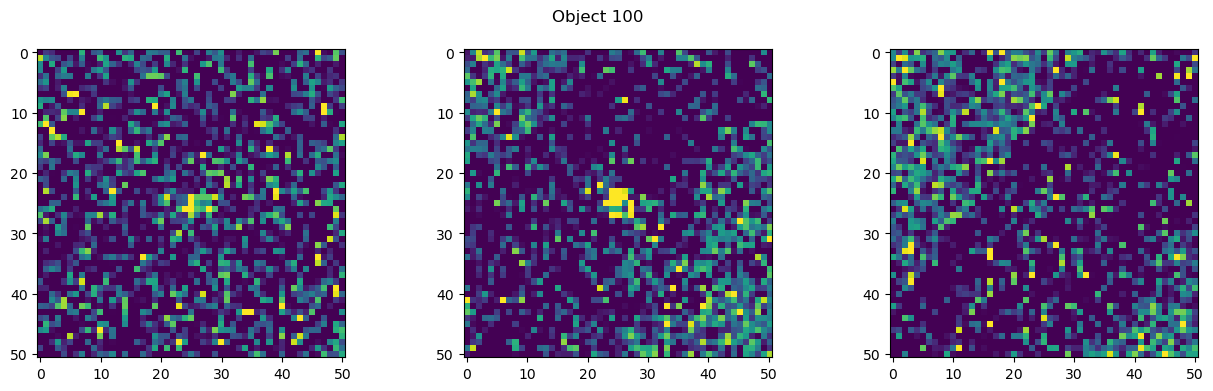

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4), gridspec_kw={'wspace': 0.1})

obj = 100

upp = 0.99
low = 0.5

fig.suptitle(f'Object {obj}')

# Plot into each subplot
axs[0].imshow(data_z['VIGNET_u' + suffix][obj], vmin=np.nanquantile(data_z['VIGNET_u' + suffix][obj], low), 
vmax=np.nanquantile(data_z['VIGNET_u' + suffix][obj], upp))

axs[1].imshow(data_z['VIGNET_b' + suffix][obj], vmin=np.nanquantile(data_z['VIGNET_b' + suffix][obj], low), 
vmax=np.nanquantile(data_z['VIGNET_b' + suffix][obj], upp))

axs[2].imshow(data_z['VIGNET_g' + suffix][obj], vmin=np.nanquantile(data_z['VIGNET_g' + suffix][obj], low), 
vmax=np.nanquantile(data_z['VIGNET_g' + suffix][obj], upp))

### Import CNN model

In [7]:
path = os.getcwd() + '/Tensorflow_models/cnn_redshift' + suffix + '.keras'

cnn_model = tf.keras.models.load_model(path)

### CNN test data and predictions

In [8]:
data_path = os.getcwd().replace('ml_redshifts', 'data') + '/cnn_data/'

trainx = np.load(data_path + 'trainx_cnn' + suffix + '.npy')
trainy = np.load(data_path + 'trainy_cnn' + suffix + '.npy')
testx = np.load(data_path + 'testx_cnn' + suffix + '.npy')
testy = np.load(data_path + 'testy_cnn' + suffix + '.npy')

### CNN predictions

In [9]:
cnn_pred_train = cnn_model.predict(trainx)
cnn_pred_test = cnn_model.predict(testx)

298/298 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


### CNN comparison

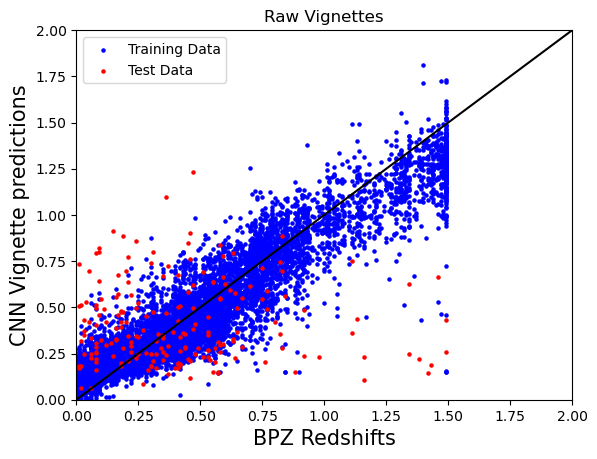

In [10]:
plt.scatter(trainy, cnn_pred_train, s=5, c='b', label='Training Data')
plt.scatter(testy, cnn_pred_test, s=5, c='r', label='Test Data')

one_to_one = np.linspace(0, 2, 100)
plt.plot(one_to_one, one_to_one, c='k')

plt.xlim(0,2)
plt.ylim(0,2)

plt.xlabel('BPZ Redshifts', fontsize = 15)
plt.ylabel('CNN Vignette predictions', fontsize = 15)
plt.title('Raw Vignettes')
plt.legend()

### Make a histogram that shows the difference between true and predicted redshift

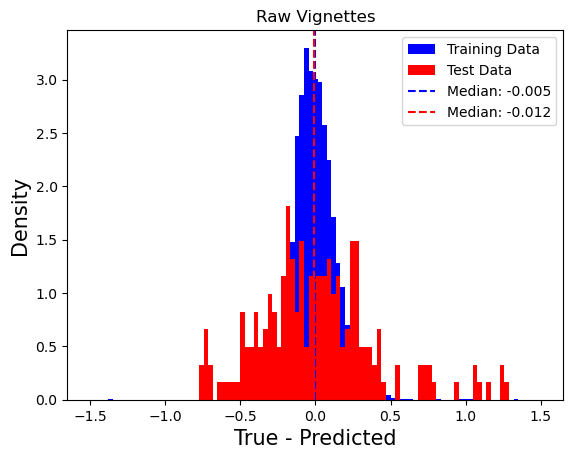

In [11]:
diff_train = trainy - cnn_pred_train
diff_test = testy - cnn_pred_test

bins = np.linspace(-1.5, 1.5, 100)

plt.hist(diff_train, density = True, color='blue', bins=bins, label='Training Data')
plt.hist(diff_test, density = True,color='red', bins=bins, label='Test Data')

plt.axvline(np.median(diff_train), c = 'blue', linestyle = '--', label = f'Median: {np.round(np.median(diff_train), 3)}')
plt.axvline(np.median(diff_test), c = 'red', linestyle = '--', label = f'Median: {np.round(np.median(diff_test), 3)}')

plt.xlabel('True - Predicted', fontsize = 15)
plt.ylabel('Density', fontsize = 15)
plt.title('Raw Vignettes')
plt.legend()

# Jax implementation

In [2]:
import jax

### Import parameters

In [3]:
suffix_jax = ''

#save_path = os.getcwd() + '/Jax_models/cnn_model_params' + suffix_jax + '.pkl'
save_path = '/home/habjan.e/SuperBIT_code/Redshift_ml/ml_redshifts/Jax_models/cnn_model_params.pkl'

with open(save_path, 'rb') as f:
    loaded_params = pickle.load(f)

### Import model

In [4]:
import sys
sys.path.append(os.getcwd() + '/Jax_models')
from jax_models import CNNModel
model = CNNModel()

### Import jax data

In [5]:
jax_suffix = ''

data_path = os.getcwd().replace('ml_redshifts', 'data') + '/cnn_data/'

trainx = np.load(data_path + 'trainx_cnn_jax' + jax_suffix + '.npy')
trainy = np.load(data_path + 'trainy_cnn_jax' + jax_suffix + '.npy')
testx = np.load(data_path + 'testx_cnn_jax' + jax_suffix + '.npy')
testy = np.load(data_path + 'testy_cnn_jax' + jax_suffix + '.npy')

### Classify

In [6]:
rng = jax.random.PRNGKey(42) 

train_sams = 500

preds_train = model.apply({'params': loaded_params}, trainx[:train_sams], training=False)
preds_test = model.apply({'params': loaded_params}, testx, training=False)

#preds_train = model.apply({'params': loaded_params}, trainx[:train_sams], rngs={'dropout': rng}, training=False)
#preds_test = model.apply({'params': loaded_params}, testx, rngs={'dropout': rng}, training=False)

preds_train = preds_train.squeeze()
preds_test = preds_test.squeeze()

### Make a scatter plot of the jax classification

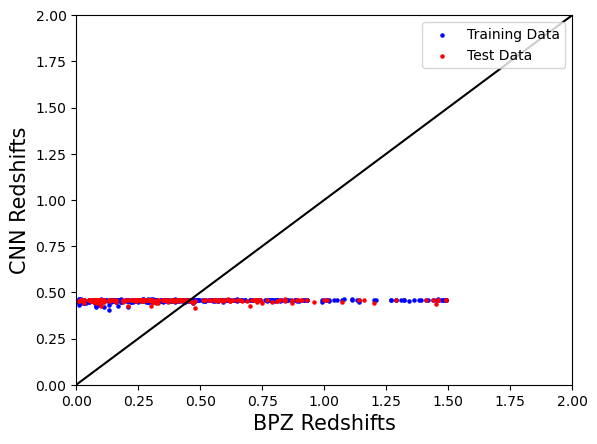

In [7]:
plt.scatter(trainy[:train_sams], preds_train, s=5, c='b', label='Training Data')
plt.scatter(testy, preds_test, s=5, c='r', label='Test Data')

one_to_one = np.linspace(0, 2, 100)
plt.plot(one_to_one, one_to_one, c='k')

plt.xlim(0,2)
plt.ylim(0,2)

plt.xlabel('BPZ Redshifts', fontsize = 15)
plt.ylabel('CNN Redshifts', fontsize = 15)
plt.legend(loc = 'upper right')